# Aufgabe: Statistische Grundlagen

Versuchen Sie, Diskriminierung beim Gehalt mit Census Datensatz aufzuzeigen.

### 1. Laden Sie den Census Datensatz mittels Pandas in Ihre Notebook:

In [78]:
# Zum Beispiel zur Darstellung
import matplotlib.pyplot as plt

# Für den Umgang mit Arrays
import numpy as np
import pandas as pd
import os

from scipy import stats

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

import math

from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from matplotlib import cm
# Importieren sie benötigte Funktionen für die Modelle und statistische Auswertung


In [69]:
# Laden des Datensatzes und Vorbereitung der Daten wie in 04 Einführung Python
census = pd.read_csv(
    os.path.join("..", "..", "..", "data", "census.csv"), sep=",", header=0
)
census.head(10)

#census["sex"] = census["sex"].replace({" Male": 1, " Female": 0})
#le = LabelEncoder()  # nicht geeignet für Modellierung mit Regression oder kNN, da die Werte eine Ordnung suggerieren, die nicht existiert. Besser wäre dann One-Hot-Encoding.
#census["education"] = le.fit_transform(census["education"])
#census["workclass"] = le.fit_transform(census["workclass"])
#census["occupation"] = le.fit_transform(census["occupation"])
#census["native-country"] = le.fit_transform(census["native-country"])
#census["marital-status"] = le.fit_transform(census["marital-status"])
#census["relationship"] = le.fit_transform(census["relationship"])
#census["race"] = le.fit_transform(census["race"])
#census["target"] = le.fit_transform(census["target"])

#census.head(10)

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,9th,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,HS-grad,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,Masters,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


### 2. Führen Sie für alle relevante Features eine explorative Datenanalyse zusammen: erstellen Sie eine visuelle Übersicht über den Datensatz

C:\Users\fried\AppData\Local\Temp\ipykernel_12568\2222518862.py:15: DeprecationWarning: Please import `gaussian_kde` from the `scipy.stats` namespace; the `scipy.stats.kde` namespace is deprecated and will be removed in SciPy 2.0.0.
  density = stats.kde.gaussian_kde(census[col])


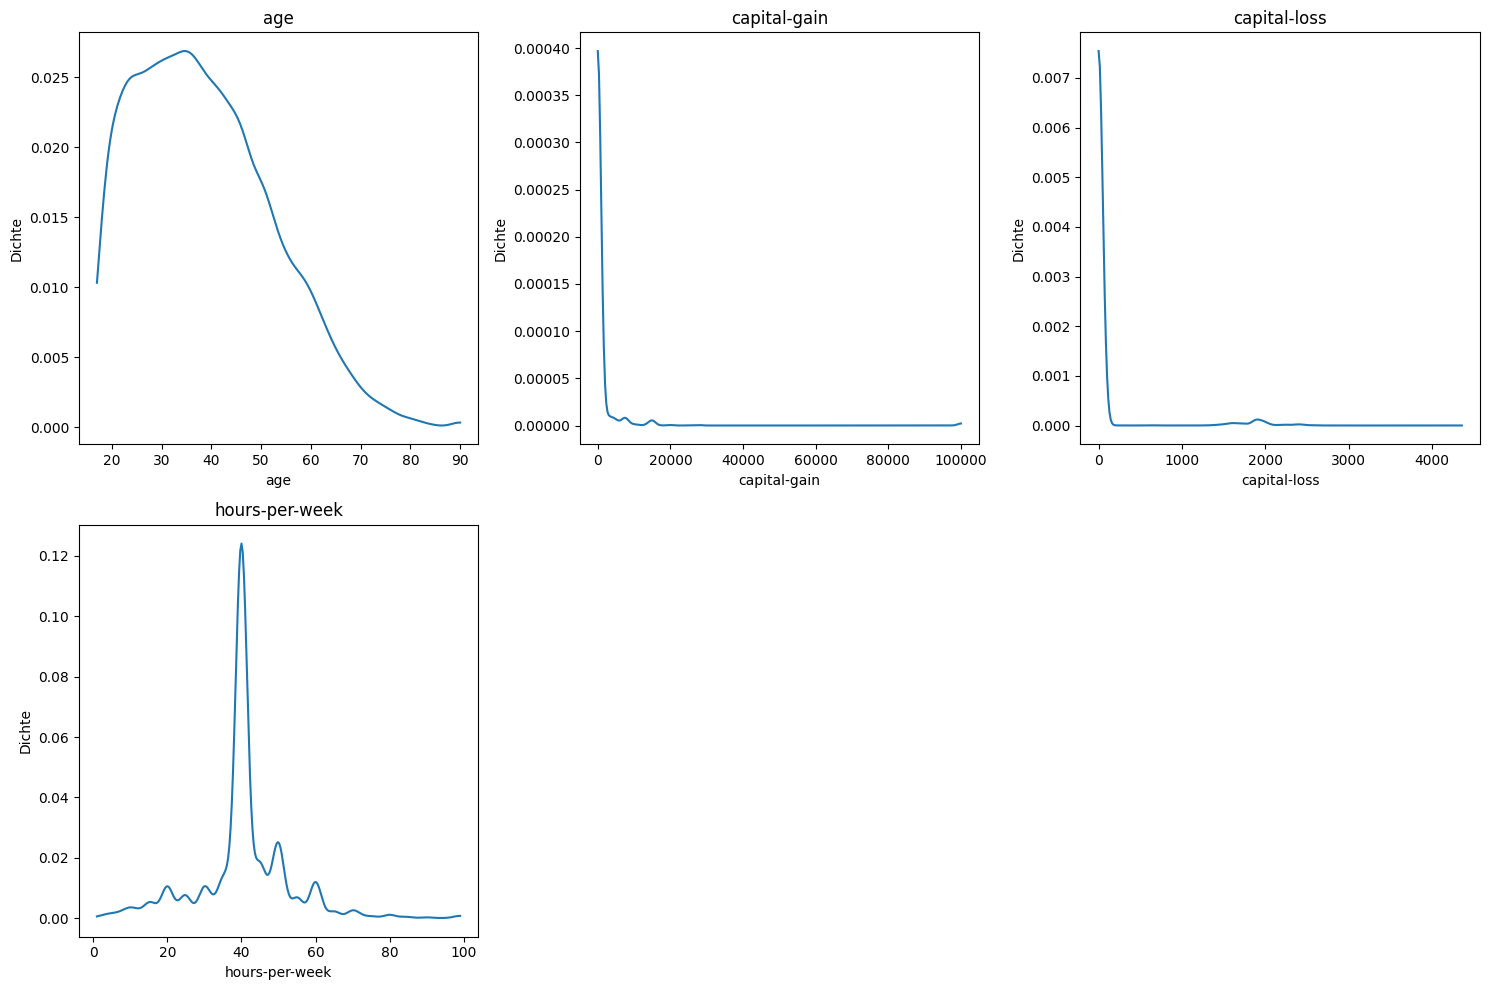

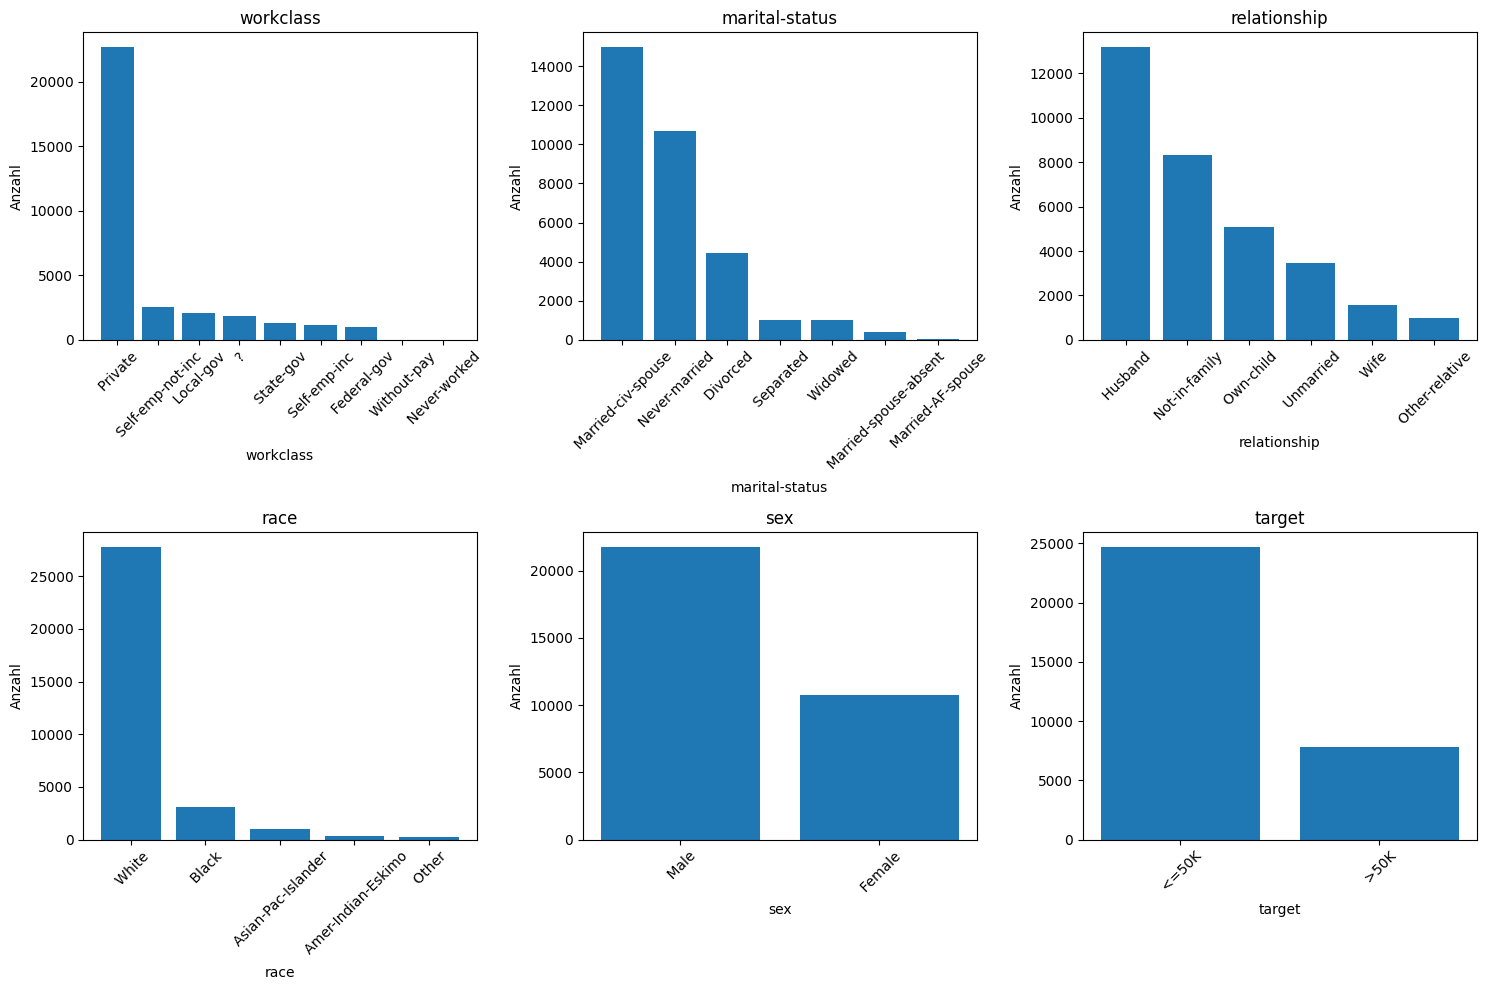

In [48]:
# Bibliothek zur Darstellung der Daten


# welche Plots könnten hier sinnvoll sein um die Verteilung der Features darzustellen?
# jedes Feature kann in einem eigenen Diagramm dargestellt werden

numeric_cols = census.select_dtypes(include=[np.number]).columns
n_cols_subplot = 3
n_rows = math.ceil(len(numeric_cols) / n_cols_subplot)

fig, axes = plt.subplots(n_rows, n_cols_subplot, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    density = stats.kde.gaussian_kde(census[col])
    x = np.linspace(census[col].min(), census[col].max(), 300)
    axes[i].plot(x, density(x))
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Dichte')

# Verstecke leere Subplots, falls weniger Spalten als Plätze
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Balkendiagramme für kategorische und binäre Variablen (Spalten mit wenigen einzigartigen Werten)
categorical_cols = [col for col in census.columns if census[col].nunique() <= 10]  # Spalten mit <= 10 einzigartigen Werten als kategorisch behandeln
n_cols_subplot = 3
n_rows = math.ceil(len(categorical_cols) / n_cols_subplot)

fig, axes = plt.subplots(n_rows, n_cols_subplot, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    counts = census[col].value_counts()
    axes[i].bar(counts.index.astype(str), counts.values)  # index als string für bessere Darstellung
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Anzahl')
    axes[i].tick_params(axis="x", rotation=45)

# Verstecke leere Subplots, falls weniger Spalten als Plätze
for j in range(len(categorical_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()




### 3. Finden Sie Auffälligkeiten im Datensatz. Welches Visualisierungstool könnte dabei hilfreich sein?

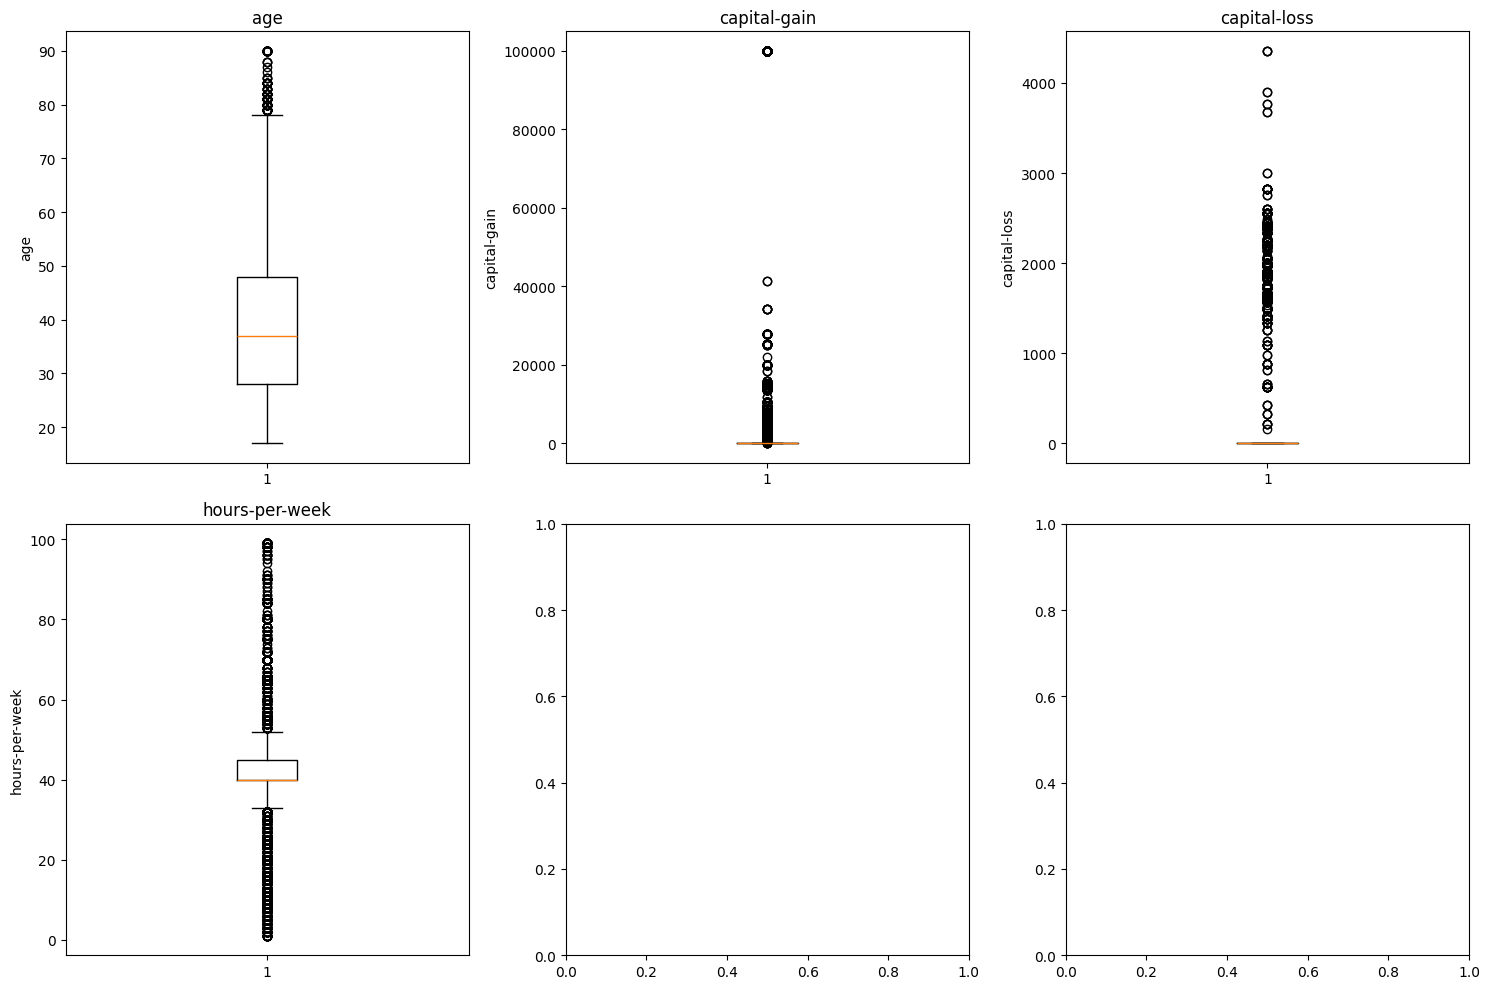

In [37]:
# machen Sie sich mit den Arten von Diagrammen in matplotlib vertraut

#pd.plotting.scatter_matrix(census[["age", "education", "hours-per-week", "marital-status" ,"sex", "race", "occupation", "workclass","target"]], c="#1ACC94")
# Boxplots für alle numerischen Features mit einer Schleife
import math

# Wähle nur numerische Spalten aus
numeric_cols = census.select_dtypes(include=[np.number]).columns

# Anzahl der Spalten und Zeilen für Subplots (z.B. 3 pro Reihe)
n_cols_subplot = 3
n_rows = math.ceil(len(numeric_cols) / n_cols_subplot)

fig, axes = plt.subplots(n_rows, n_cols_subplot, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flache Liste für einfache Iteration

# Schleife durch die numerischen Spalten
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(census[col])
    axes[i].set_title(f"{col}")
    axes[i].set_ylabel(col)

# Verstecke leere Subplots, falls weniger Spalten als Plätze
#for j in range(len(numeric_cols), len(axes)):
#    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Es sollten statistische Größen und Ausreißer sichtbar sein

### 4. Geben Sie eine erste Abschätzung, welche Features für die Vorhersage des Targets (Einkommen größer oder kleiner als 50k) gut geeignet sind und versuchen Sie mithilfe der betrachteten statistischen Werkzeug Diskriminierung beim Gehalt aufzuzeigen.

In [54]:
# Analysieren Sie den Zusammenhang der Features und der Zielvariable
le = LabelEncoder()
census["target"] = le.fit_transform(census["target"])
#census.head()
#census["target", "age", "hours-per-week", "capital-gain", "capital-loss"].corr()

# Berechne die Korrelation aller numerischen Variablen mit 'target'
numeric_cols = census.select_dtypes(include=[np.number]).columns
correlations = {}

for col in numeric_cols:
    correlation = census[col].corr(census['target'])
    correlations[col] = correlation
    print(f"Korrelation zwischen {col} und target: {correlation:.4f}")

# Sortiere die Korrelationen nach absoluter Größe
sorted_correlations = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
print("\nSortiert nach absoluter Korrelationsstärke:")
for col, corr in sorted_correlations:
    print(f"{col}: {corr:.4f}")

Korrelation zwischen age und target: 0.2340
Korrelation zwischen capital-gain und target: 0.2233
Korrelation zwischen capital-loss und target: 0.1505
Korrelation zwischen hours-per-week und target: 0.2297
Korrelation zwischen target und target: 1.0000

Sortiert nach absoluter Korrelationsstärke:
target: 1.0000
age: 0.2340
hours-per-week: 0.2297
capital-gain: 0.2233
capital-loss: 0.1505


In [65]:
le = LabelEncoder()  # nicht geeignet für Modellierung mit Regression oder kNN, da die Werte eine Ordnung suggerieren, die nicht existiert. Besser wäre dann One-Hot-Encoding.
census["education"] = le.fit_transform(census["education"])
census["workclass"] = le.fit_transform(census["workclass"])
census["occupation"] = le.fit_transform(census["occupation"])
census["native-country"] = le.fit_transform(census["native-country"])
census["marital-status"] = le.fit_transform(census["marital-status"])
census["relationship"] = le.fit_transform(census["relationship"])
census["race"] = le.fit_transform(census["race"])
census["target"] = le.fit_transform(census["target"])

# Berechne die Korrelationsmatrix aller numerischen Variablen
numeric_cols = census.select_dtypes(include=[np.number]).columns
correlations = {}

for col in numeric_cols:
    correlation = census[col].corr(census["target"])
    correlations[col] = correlation
    #print(f"Korrelation zwischen {col} und target: {correlation:.4f}")

sorted_correlations = sorted(
    correlations.items(), key=lambda x: abs(x[1]), reverse=True
)
print("\nSortiert nach absoluter Korrelationsstärke:")
for col, corr in sorted_correlations:
    print(f"{col}: {corr:.4f}")


Sortiert nach absoluter Korrelationsstärke:
target: 1.0000
relationship: -0.2509
age: 0.2340
hours-per-week: 0.2297
capital-gain: 0.2233
sex: 0.2160
marital-status: -0.1993
capital-loss: 0.1505
education: 0.0793
occupation: 0.0755
race: 0.0718
workclass: 0.0516
native-country: 0.0158


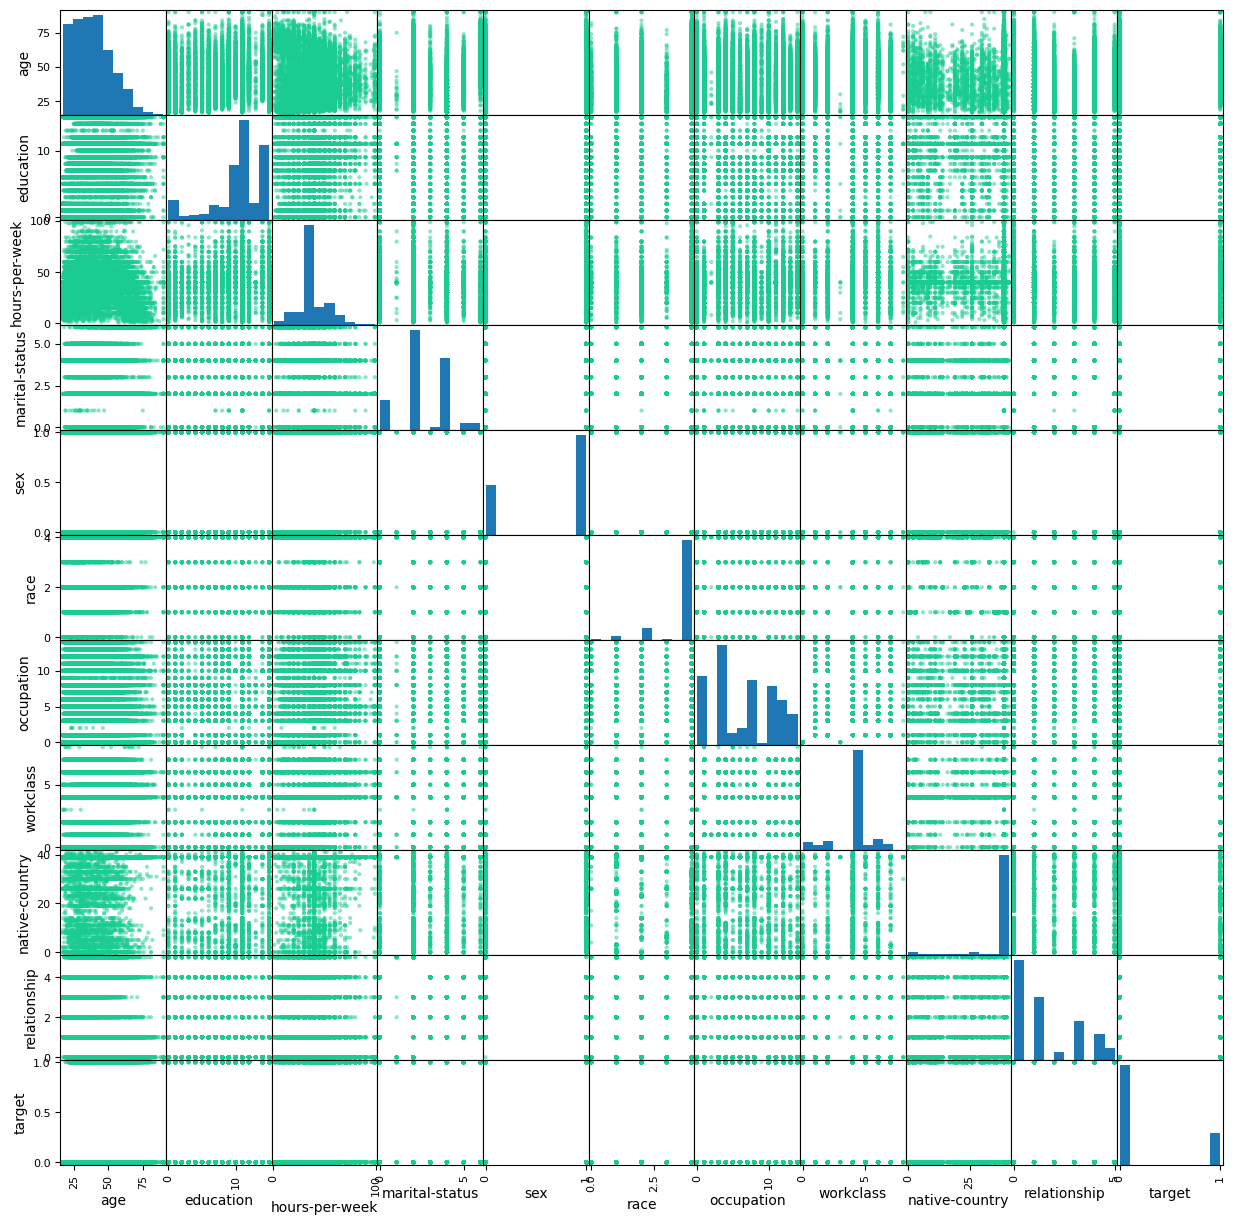

In [67]:
census["sex"] = census["sex"].replace({" Male": 1, " Female": 0})
le = LabelEncoder()  # nicht geeignet für Modellierung mit Regression oder kNN, da die Werte eine Ordnung suggerieren, die nicht existiert. Besser wäre dann One-Hot-Encoding.
census["education"] = le.fit_transform(census["education"])
census["workclass"] = le.fit_transform(census["workclass"])
census["occupation"] = le.fit_transform(census["occupation"])
census["native-country"] = le.fit_transform(census["native-country"])
census["marital-status"] = le.fit_transform(census["marital-status"])
census["relationship"] = le.fit_transform(census["relationship"])
census["race"] = le.fit_transform(census["race"])
census["target"] = le.fit_transform(census["target"])

pd.plotting.scatter_matrix(
    census[
        [
            "age",
            "education",
            "hours-per-week",
            "marital-status",
            "sex",
            "race",
            "occupation",
            "workclass",
            "native-country",
            "relationship",
            "target",
        ]
    ],
    c="#1ACC94",
    figsize=(15, 15),  # Anpassung der Figure-Größe (Breite, Höhe in Zoll)
)
plt.show()

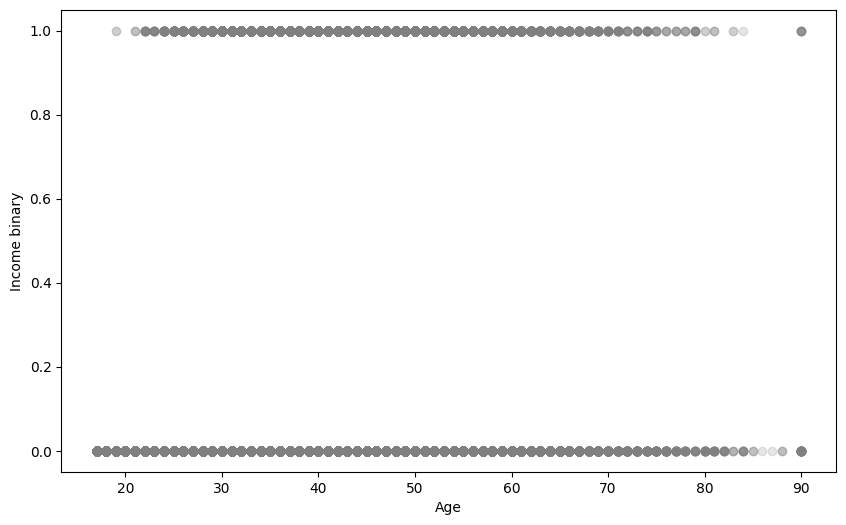

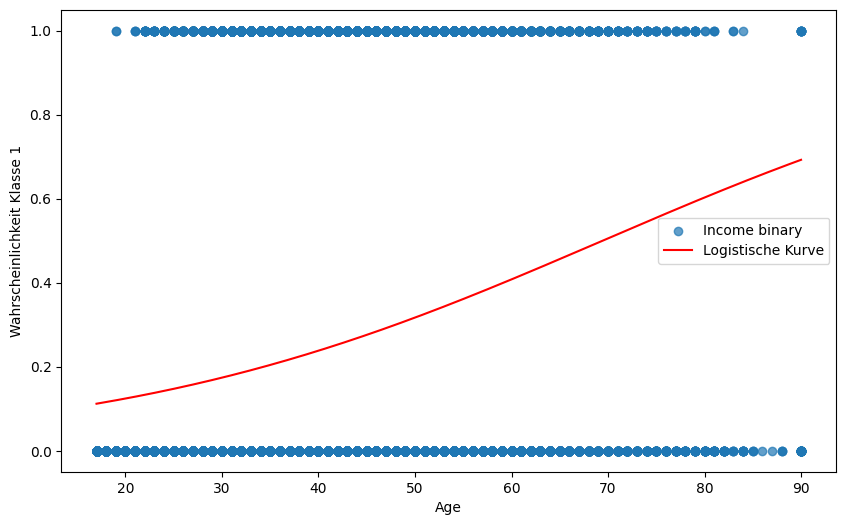

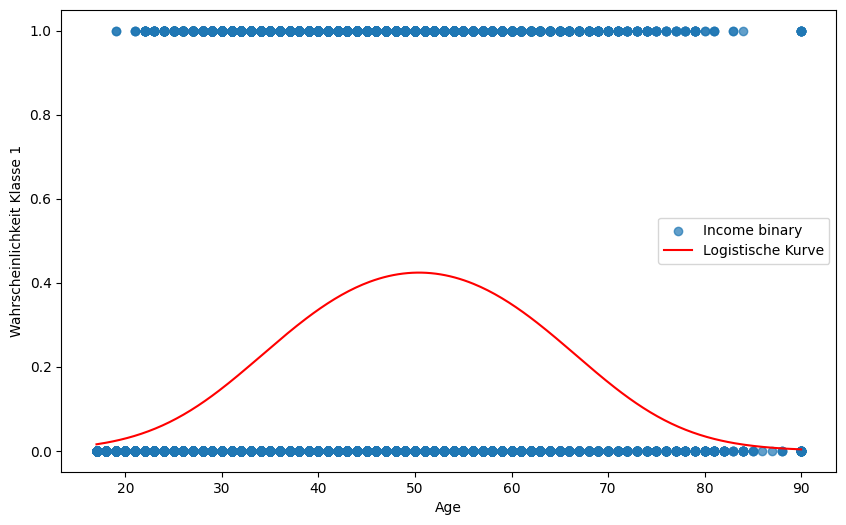

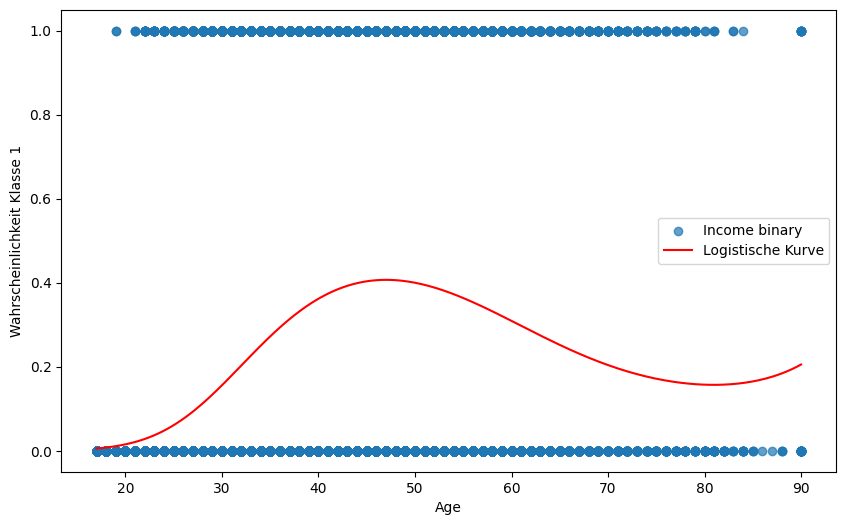

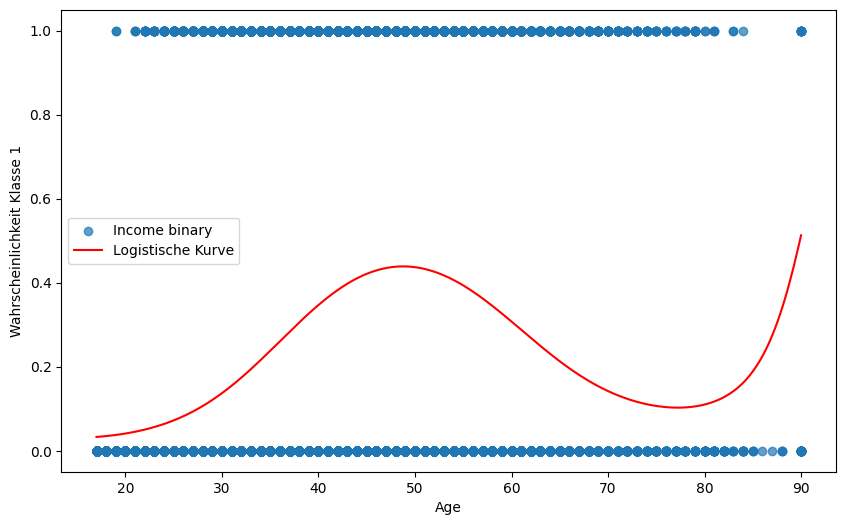

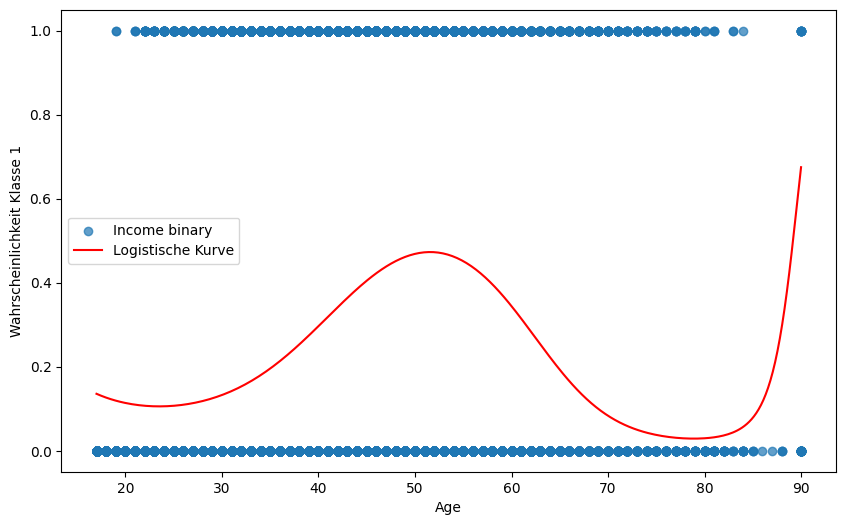

c:\Code-Projekte\FullStackMachineLearning\full-stack-machine-learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


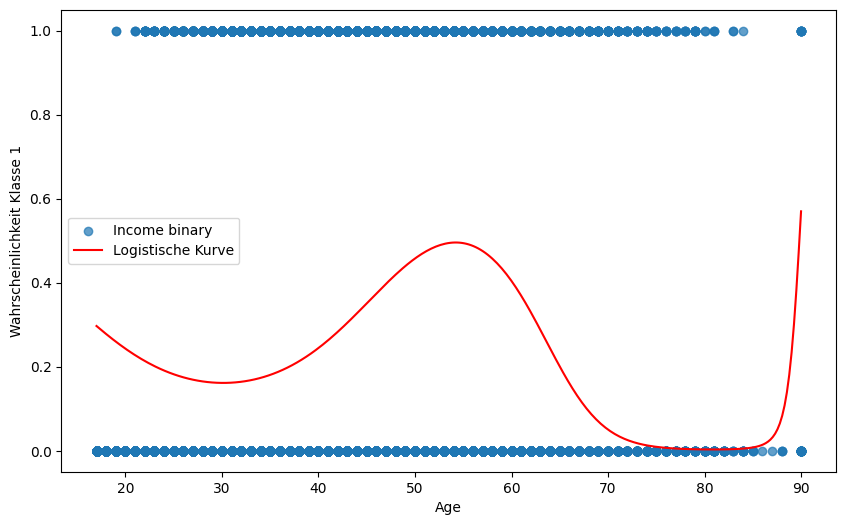

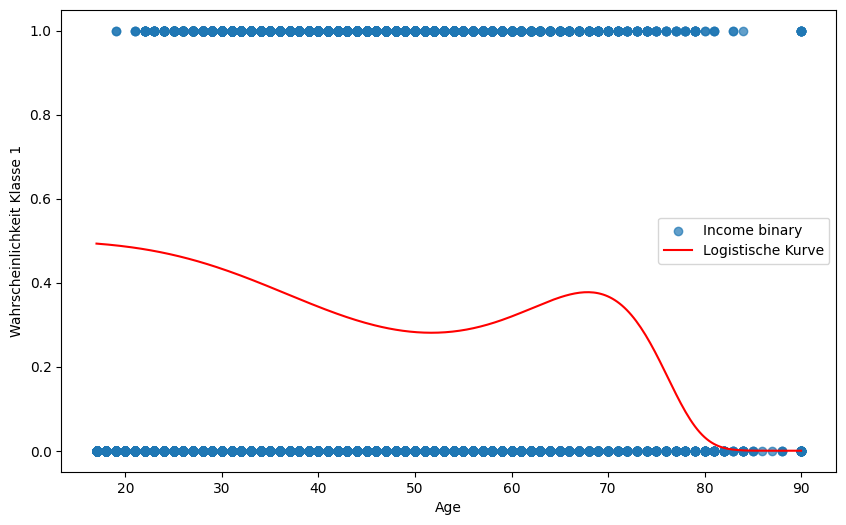

In [ ]:
le = LabelEncoder()
census["target"] = le.fit_transform(census["target"])
#census.head()
target = census["target"]
age = census["age"]
# Visualisierung der Daten mit farbiger Unterscheidung
plt.figure(figsize=(10, 6))
# Punkte für "bestanden" (grün)
plt.scatter(
    age,
    target,
    color="gray",
    label="Bestanden",
    alpha=0.2,
)

# Achsenbeschriftungen und Titel
plt.xlabel("Age")
plt.ylabel("Income binary")
#plt.title("Ergebnisse nach Lernstunden")
#plt.legend()
plt.show()


for degree in range(1, 2):
    poly = PolynomialFeatures(degree)  # hier Grad 1 (linear) – kann erhöht werden
    x_poly = poly.fit_transform(age.to_numpy().reshape(-1, 1))
    logreg = LogisticRegression()
    logreg.fit(x_poly, target)
    # Vorhersagewahrscheinlichkeiten und Klassenvorhersage
    probs = logreg.predict_proba(x_poly)[:, 1]  # Wahrscheinlichkeit für Klasse 1
    preds = logreg.predict(x_poly)
    accuracy = np.mean(preds == target)
    # print("Wahrscheinlichkeiten:\n", probs)
    # print("Klassenvorhersage:\n", preds)
    # print(f"Accuracy: {accuracy:.4f}")

    # Visualisierung über Wertebereich
    x_range = np.linspace(age.min(), age.max(), 300).reshape(-1, 1)
    x_poly_range = poly.transform(x_range)
    y_prob_range = logreg.predict_proba(x_poly_range)[:, 1]
    plt.figure(figsize=(10, 6))
    plt.scatter(age, target, label="Income binary", alpha=0.7)
    plt.plot(x_range, y_prob_range, color="red", label="Logistische Kurve")
    plt.xlabel("Age")
    plt.ylabel("Wahrscheinlichkeit Klasse 1")
    plt.legend()
    plt.show()
